In [1]:
import cv2
from models import Model
from hydra import initialize, compose
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import numpy as np

with initialize(version_base=None, config_path="configs"):
    cfg = compose(config_name="inference")

print(OmegaConf.to_yaml(cfg))

/Users/albertomarengo/Bitstrapped-Project/my_yolo/yol-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


model:
  name: mlp
  image_size:
  - 512
  - 512
  - 3
  backbone_name: resnet101
  fpn_channels: 128
  num_anchors: 16
  nms_threshold: 0.55
  score_threshold: 0.05
  metadata:
    best_model_folder: model
dataset:
  train: ../Dataset/train/Vehicle registration plate
  val: ../Dataset/validation/Vehicle registration plate
  nc: 2
  names:
  - __background__
  - Reg-plate
  metadata:
    workspace: alberto-marengo
    project: licence-plate-detection
    dataset: licence-plate-detection
    version: 1
    url: https://www.dropbox.com/s/k81ljpmzy3fgtx9/Dataset.zip?dl=1



In [2]:
cfg.dataset.names

['__background__', 'Reg-plate']

In [3]:
model = Model(cfg)

/Users/albertomarengo/Bitstrapped-Project/my_yolo/yol-venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/albertomarengo/Bitstrapped-Project/my_yolo/yol-venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
print(model.model)

Detector(
  (backbone): Backbone(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (rel

In [5]:
pred = model("samples/1f0e643b125f00ec.jpg")

In [14]:
def draw_bbox(image, boxes, labels=None, conf_scores = None, color=(255, 0, 0), thickness=-1):

    for idx, box in enumerate(boxes):
        xmin = box[0]
        ymin = box[1]
        xmax = box[2]
        ymax = box[3]

        image = np.ascontiguousarray(image)
        image = cv2.rectangle(image, (xmin, ymin), (xmax, ymax), color, thickness)

        if labels:
            display_text = str(labels[idx])

            (text_width, text_height), _ = cv2.getTextSize(display_text, cv2.FONT_HERSHEY_SIMPLEX, 1.0, 2)

            cv2.rectangle(image, (xmin, ymin - int(0.9 * text_height)), (xmin + int(0.4*text_width), ymin), color, -1)


            image = cv2.putText(
                image,
                display_text,
                (xmin, ymin - int(0.3 * text_height)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.4,
                (0, 0, 0),
                1,
            )

        elif conf_scores:
            display_text = str(round(conf_scores[idx], 4)*100) + '%'

            (text_width, text_height), _ = cv2.getTextSize(display_text, cv2.FONT_HERSHEY_SIMPLEX, 1.0, 2)

            cv2.rectangle(image, (xmin, ymin - int(0.9 * text_height)), (xmin + int(0.4*text_width), ymin), color, -1)


            image = cv2.putText(
                image,
                display_text,
                (xmin, ymin - int(0.3 * text_height)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.4,
                (0, 0, 0),
                1,
            )

    return image

def plot_predictions(prediction):
    # Define subplots
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(10, 10),
    )
    # Plot Predictions.
    orig_image = draw_bbox(
        prediction['image_array'],
        np.array(prediction['final_boxes'], dtype=np.int32),
        labels=pred['class_names'],
        color=(255, 0, 0),
        thickness=2,
    )


    ax.imshow(orig_image)
    ax.axis("off")

    plt.figtext(0.50, 0.9, "Predictions", fontsize=20, color="r", ha="center")

    plt.show(block=False)

    return fig

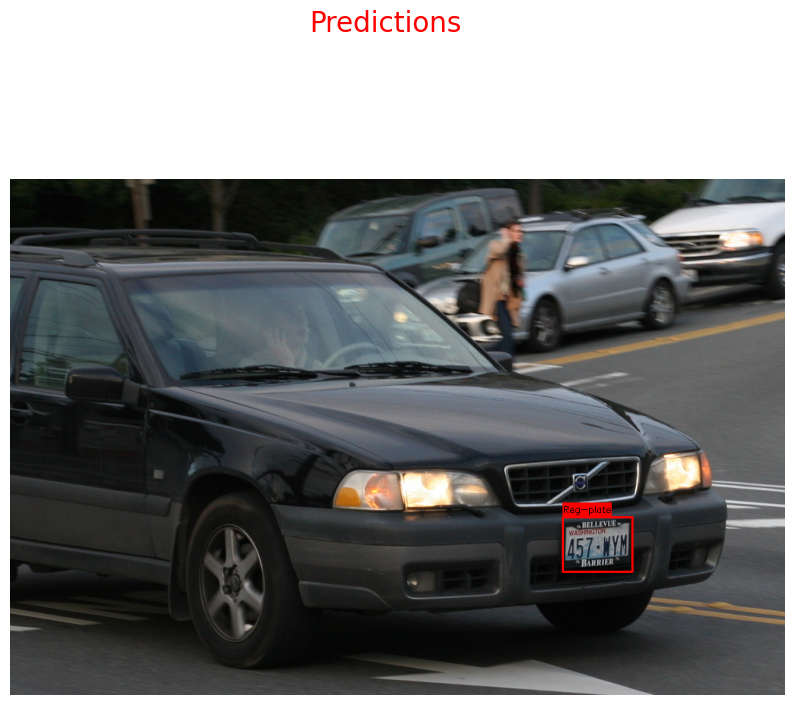

In [15]:
figure = plot_predictions(pred)